In [1]:
!git clone -q https://github.com/Mikayla-ds2/surge-sense.git

In [2]:
%cd surge-sense

/content/surge-sense


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

%pip install pmdarima
import pmdarima as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.5 MB/s eta 0:00:00a 0:00:01


In [5]:
data = pd.read_csv('/content/drive/MyDrive/daily_visits.csv')

In [6]:
data.head()

,admission_day,visit_count
0,2023-04-01,19
1,2023-04-02,13
2,2023-04-03,14
3,2023-04-04,9
4,2023-04-05,19


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   admission_day  579 non-null    object
 1   visit_count    579 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.2+ KB


In [8]:
data['admission_day'] = pd.to_datetime(data['admission_day'])

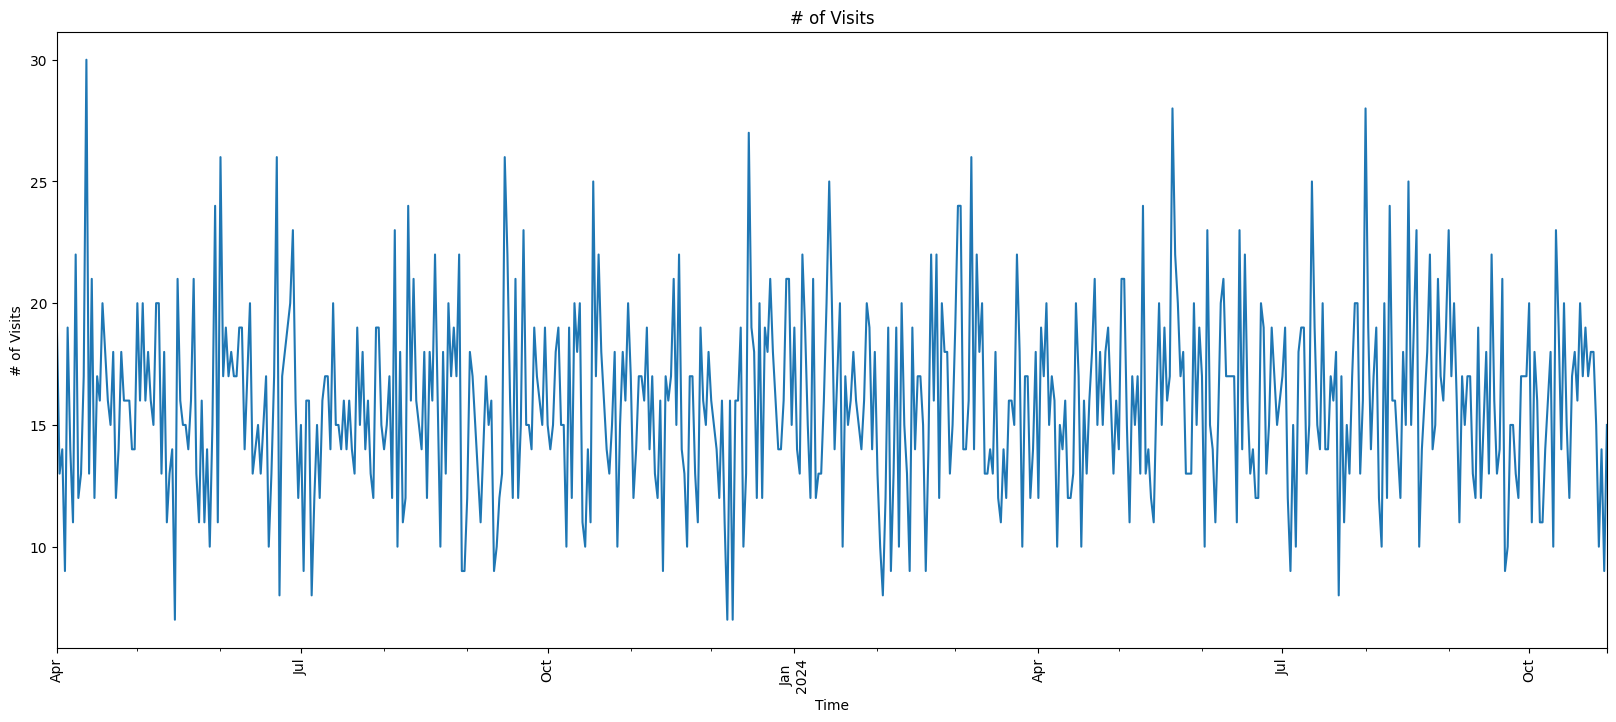

In [9]:
plot = data.plot(x='admission_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('# of Visits')
plt.xlabel('Time')
plt.ylabel('# of Visits')
plt.show()

In [10]:
data['month_day'] = data['admission_day'].dt.strftime('%m-%d')
data.head()

,admission_day,visit_count,month_day
0,2023-04-01,19,04-01
1,2023-04-02,13,04-02
2,2023-04-03,14,04-03
3,2023-04-04,9,04-04
4,2023-04-05,19,04-05


In [11]:
data['month'] = data['admission_day'].dt.strftime('%m')
data['day'] = data['admission_day'].dt.strftime('%d')
data['weekday'] = data['admission_day'].dt.day_name()
data.head()

,admission_day,visit_count,month_day,month,day,weekday
0,2023-04-01,19,04-01,04,01,Saturday
1,2023-04-02,13,04-02,04,02,Sunday
2,2023-04-03,14,04-03,04,03,Monday
3,2023-04-04,9,04-04,04,04,Tuesday
4,2023-04-05,19,04-05,04,05,Wednesday


,month_day,visit_count
222,08-10,48
232,08-20,45
141,05-21,44
258,09-15,44
142,05-22,43
152,06-01,43
284,10-11,43
291,10-18,43
102,04-12,42
154,06-03,42


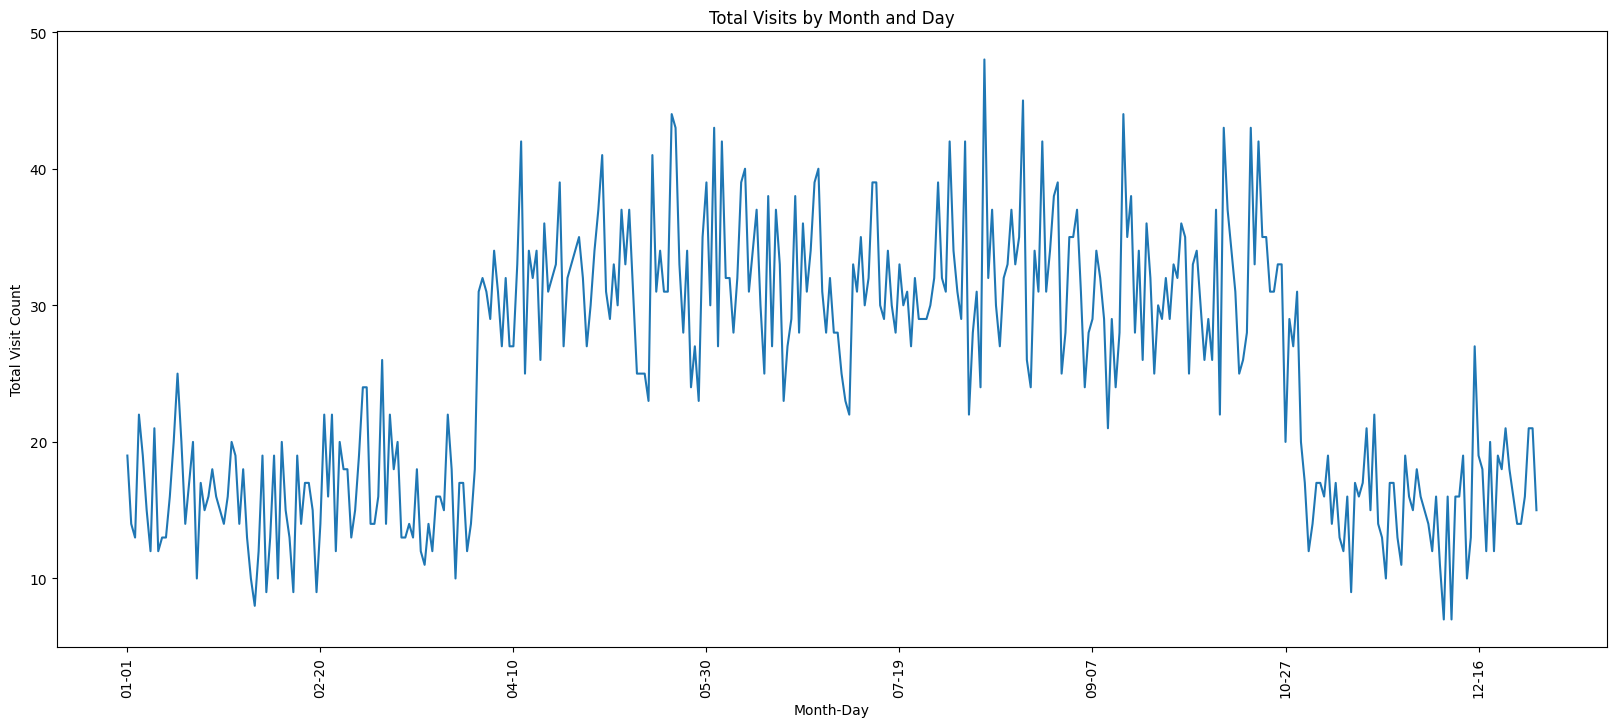

In [12]:
sum_visits = data.groupby('month_day', as_index=False)['visit_count'].sum()
agg_visits_sum = sum_visits.sort_values('month_day')

display(agg_visits_sum.loc[agg_visits_sum['visit_count'].nlargest(10).index])

plot = agg_visits_sum.plot(x='month_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('Total Visits by Month and Day')
plt.xlabel('Month-Day')
plt.ylabel('Total Visit Count')
plt.show()

,month_day,visit_count
349,12-15,27.0
66,03-07,26.0
13,01-14,25.0
61,03-02,24.0
62,03-03,24.0
222,08-10,24.0
232,08-20,22.5
3,01-04,22.0
51,02-21,22.0
53,02-23,22.0


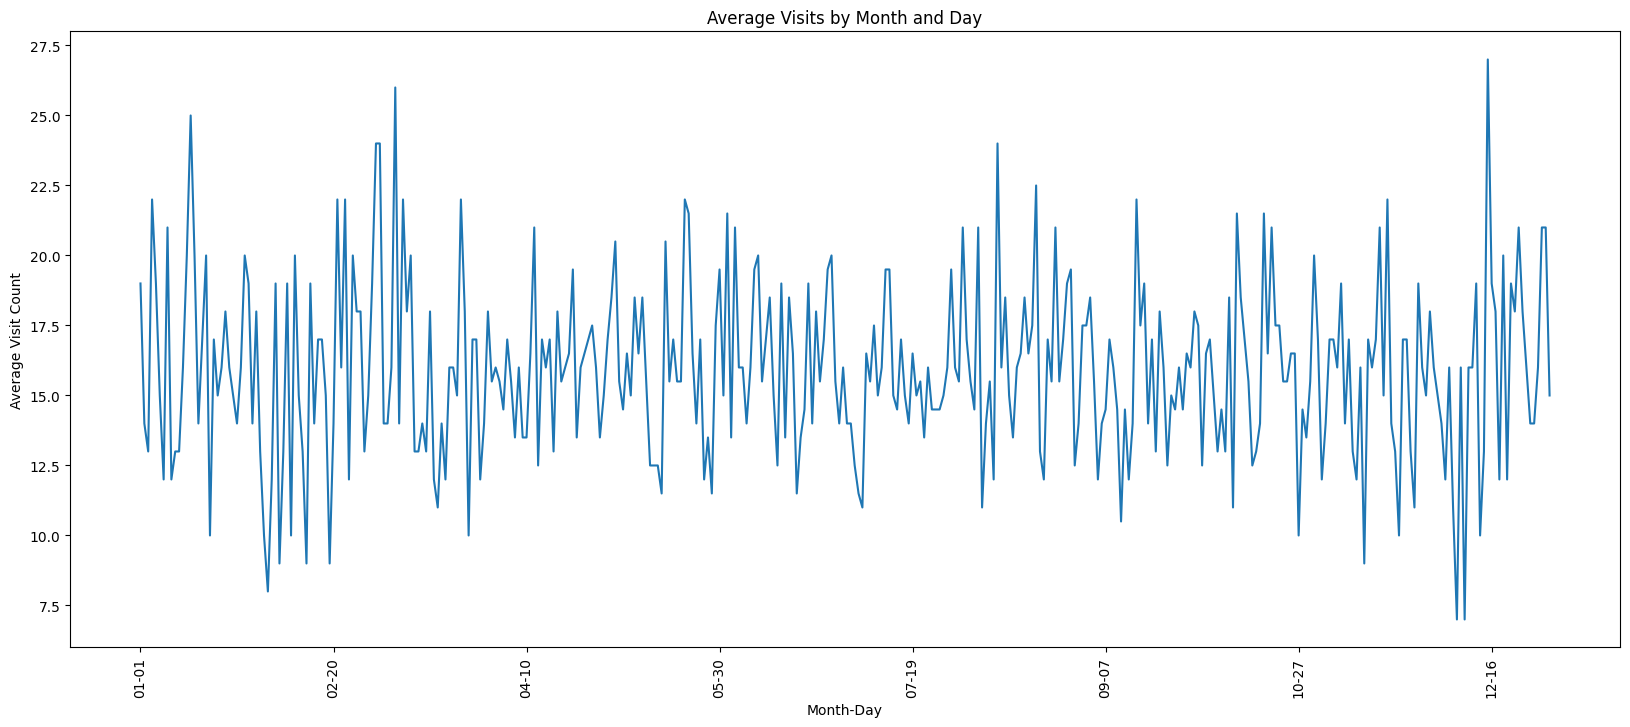

In [13]:
avg_visits = data.groupby('month_day', as_index=False)['visit_count'].mean()
agg_visits_avg = avg_visits.sort_values('month_day')

display(agg_visits_avg.loc[agg_visits_avg['visit_count'].nlargest(10).index])

plot = agg_visits_avg.plot(x='month_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Month and Day')
plt.xlabel('Month-Day')
plt.ylabel('Average Visit Count')
plt.show()

,month,visit_count
1,02,14.862069
6,07,15.354839
10,11,15.466667
8,09,15.583333
11,12,15.774194
3,04,15.800000
9,10,15.803279
4,05,16.112903
2,03,16.322581
7,08,16.516129


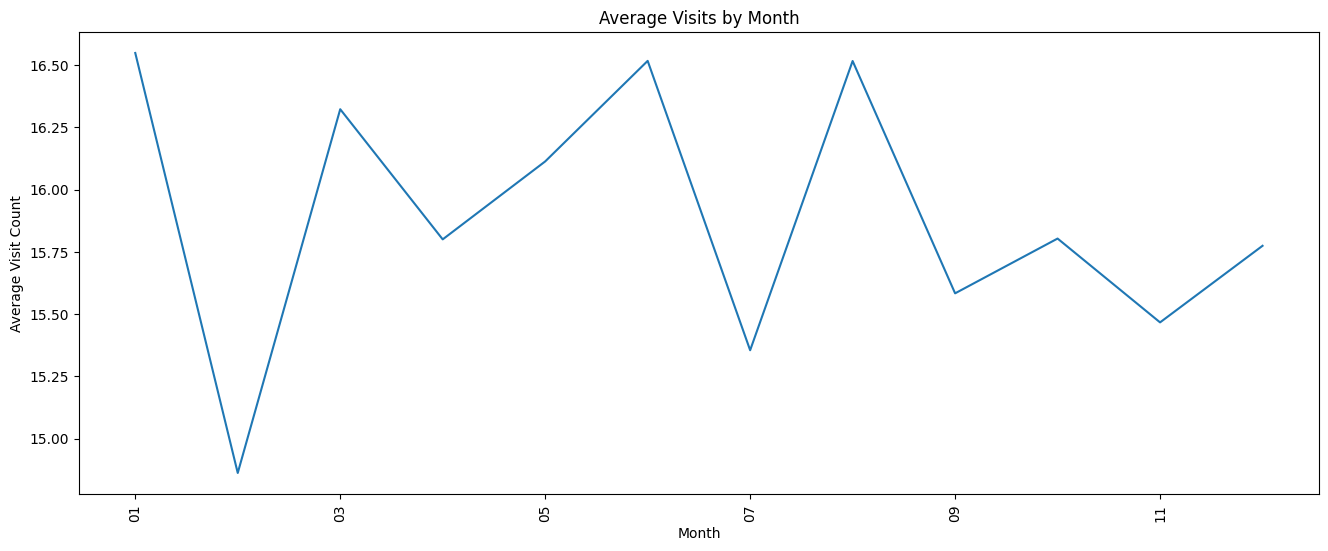

In [14]:
monthly_avg_visits = data.groupby('month', as_index=False)['visit_count'].mean()
agg_monthly_avg_visits = monthly_avg_visits.sort_values('month')

display(agg_monthly_avg_visits.loc[agg_monthly_avg_visits['visit_count'].nsmallest(12).index])

plot = agg_monthly_avg_visits.plot(x='month', y='visit_count', legend=False, figsize=(16, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Month')
plt.xlabel('Month')
plt.ylabel('Average Visit Count')
plt.show()

In [15]:
data['quarter'] = pd.PeriodIndex(data.admission_day, freq='Q')
data.head()

,admission_day,visit_count,month_day,month,day,weekday,quarter
0,2023-04-01,19,04-01,04,01,Saturday,2023Q2
1,2023-04-02,13,04-02,04,02,Sunday,2023Q2
2,2023-04-03,14,04-03,04,03,Monday,2023Q2
3,2023-04-04,9,04-04,04,04,Tuesday,2023Q2
4,2023-04-05,19,04-05,04,05,Wednesday,2023Q2


,quarter,visit_count
4,2024Q2,16.186813
5,2024Q3,16.130435
0,2023Q2,16.098901
3,2024Q1,15.934066
2,2023Q4,15.717391
6,2024Q4,15.700000
1,2023Q3,15.510870


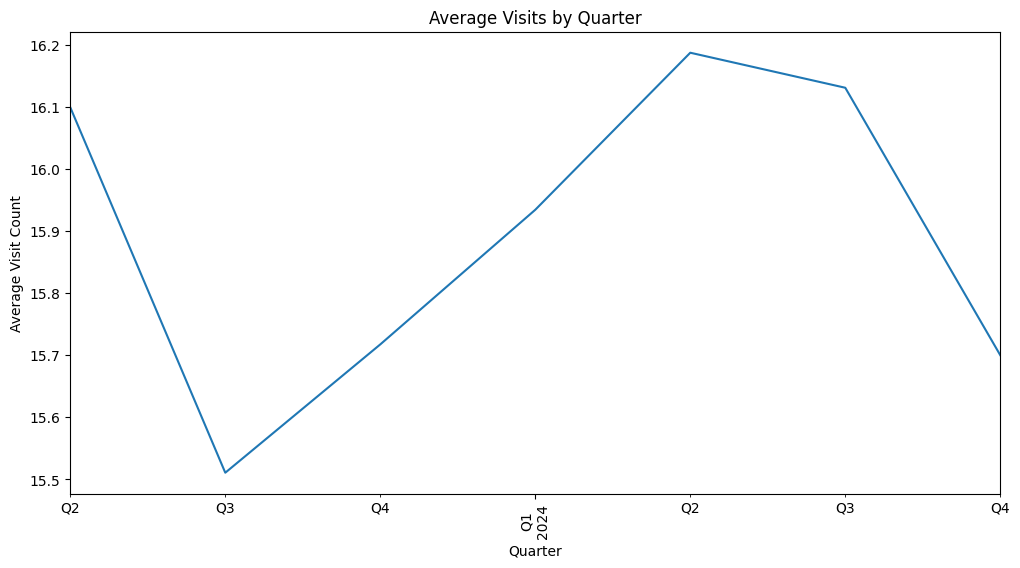

In [16]:
quarterly_avg_visits = data.groupby('quarter', as_index=False)['visit_count'].mean()
agg_visits = quarterly_avg_visits.sort_values('quarter')

display(agg_visits.loc[agg_visits['visit_count'].nlargest(10).index])    

plot = agg_visits.plot(x='quarter', y='visit_count', legend=False, figsize=(12, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Visit Count')
plt.show()

In [21]:
iso = data['admission_day'].dt.isocalendar()
data['week_sequential'] = iso['year'].astype(str) + '-W' + iso['week'].astype(str).str.zfill(2)
data['week_of_year'] = iso['week'] # week 1-52 of the year; will repeat
data.head()

,admission_day,visit_count,month_day,month,day,weekday,quarter,week_sequential,week_of_year
0,2023-04-01,19,04-01,04,01,Saturday,2023Q2,2023-W13,13
1,2023-04-02,13,04-02,04,02,Sunday,2023Q2,2023-W13,13
2,2023-04-03,14,04-03,04,03,Monday,2023Q2,2023-W14,14
3,2023-04-04,9,04-04,04,04,Tuesday,2023Q2,2023-W14,14
4,2023-04-05,19,04-05,04,05,Wednesday,2023Q2,2023-W14,14


,week_sequential,visit_count
60,2024-W21,19.285714
48,2024-W09,18.714286
9,2023-W22,18.428571
70,2024-W31,18.142857
67,2024-W28,17.857143
74,2024-W35,17.857143
49,2024-W10,17.714286
2,2023-W15,17.571429
29,2023-W42,17.571429
37,2023-W50,17.428571


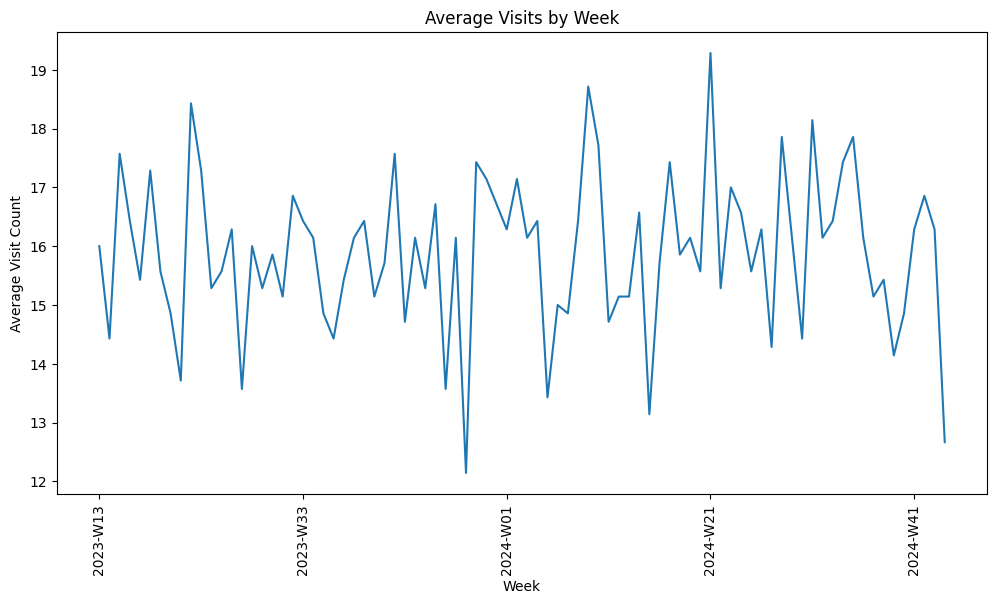

In [24]:
weekly_avg_visits = data.groupby('week_sequential', as_index=False)['visit_count'].mean()
agg_visits = weekly_avg_visits.sort_values('week_sequential')

display(agg_visits.loc[agg_visits['visit_count'].nlargest(10).index])    

plot = agg_visits.plot(x='week_sequential', y='visit_count', legend=False, figsize=(12, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Week')
plt.xlabel('Week')
plt.ylabel('Average Visit Count')
plt.show()

,week_of_year,visit_count
8,9,18.714286
9,10,17.714286
49,50,17.428571
41,42,17.214286
1,2,17.142857
22,23,17.142857
50,51,17.142857
27,28,16.928571
21,22,16.857143
33,34,16.785714


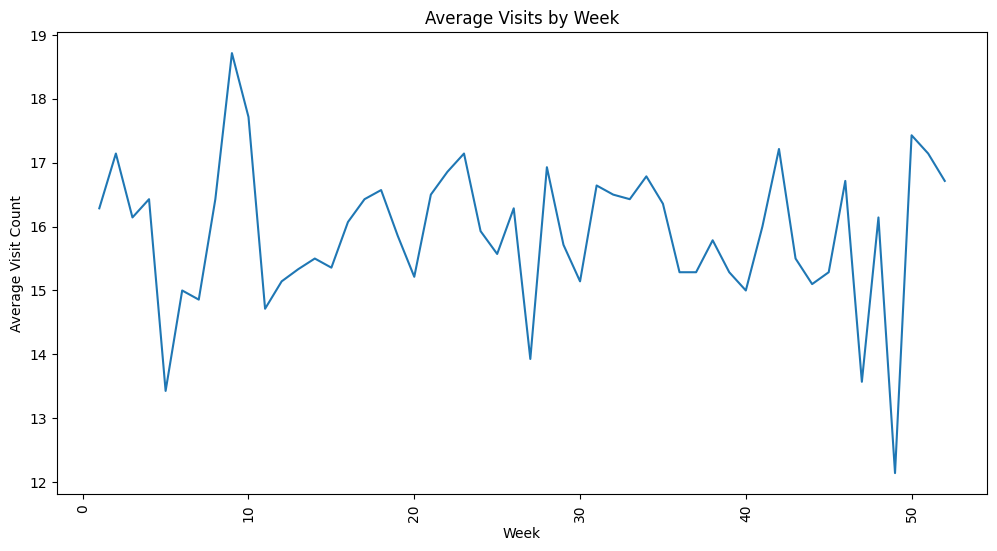

In [25]:
weekly_avg_visits = data.groupby('week_of_year', as_index=False)['visit_count'].mean()
agg_visits = weekly_avg_visits.sort_values('week_of_year')

display(agg_visits.loc[agg_visits['visit_count'].nlargest(10).index])    

plot = agg_visits.plot(x='week_of_year', y='visit_count', legend=False, figsize=(12, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Week')
plt.xlabel('Week')
plt.ylabel('Average Visit Count')
plt.show()

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   admission_day    579 non-null    datetime64[ns]
 1   visit_count      579 non-null    int64         
 2   month_day        579 non-null    object        
 3   month            579 non-null    object        
 4   day              579 non-null    object        
 5   weekday          579 non-null    object        
 6   quarter          579 non-null    period[Q-DEC] 
 7   week_sequential  579 non-null    object        
 8   week_of_year     579 non-null    UInt32        
dtypes: UInt32(1), datetime64[ns](1), int64(1), object(5), period[Q-DEC](1)
memory usage: 39.1+ KB


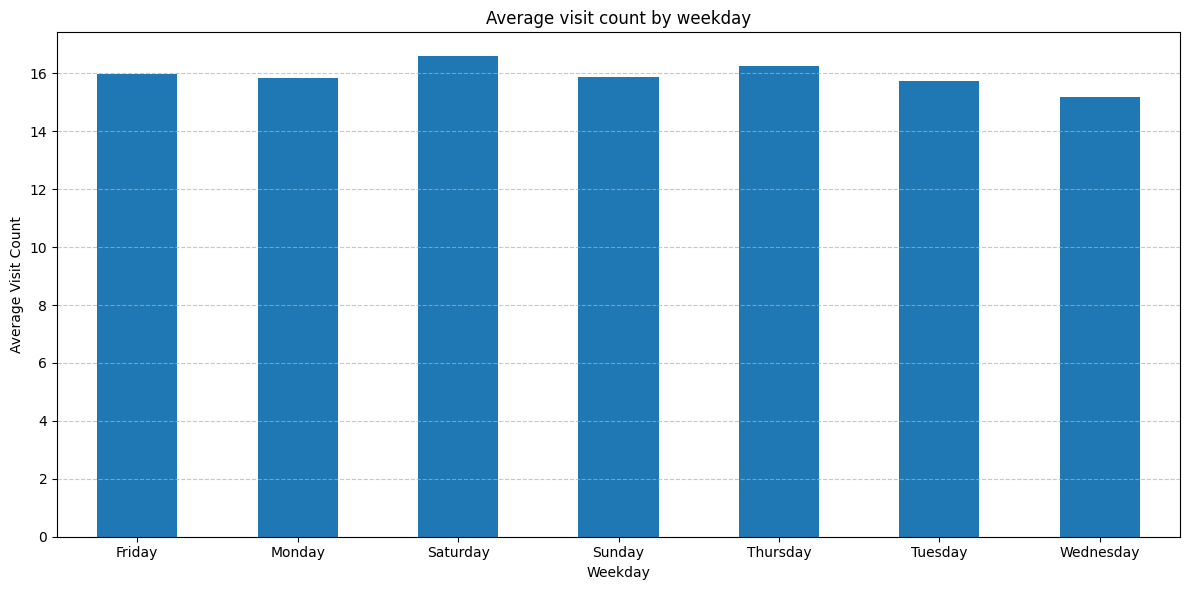

In [26]:
# quick bar plot for average visit count by weekday
mean_visits = data.groupby('weekday')['visit_count'].mean()
plt.figure(figsize=(12, 6))
mean_visits.plot(kind='bar')
plt.title('Average visit count by weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Visit Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
data.visit_count.describe()

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(data['visit_count'], bins=15)
plt.show()

first outlier detection using a threshold: z=2 are varied activity days; not necessarily entire outliers. however, August 10th, flagging for both years, needs to be investigated – which I will. 

In [ ]:
# outlier detection - 
df = data.copy()
df['z_score'] = np.abs((df['visit_count'] - df['visit_count'].mean()) / df['visit_count'].std())
outliers_z_score = df[df['z_score'] > 2]
z_outlier_percent = (len(outliers_z_score) / len(df)) * 100

print(f"Detected {len(outliers_z_score)} outliers ({z_outlier_percent:.2f}% of the dataset) using z-scores; threshold = 2.\n")

ax = data.plot(x='admission_day', y='visit_count', label="Time Series", figsize=(20, 6))
outlier_dates = matplotlib.dates.date2num(outliers_z_score['admission_day'])
ax.scatter(outlier_dates, outliers_z_score['visit_count'], color='red', label='Detected outliers')
ax.legend()
plt.show()

second outlier detection using threshold: z=3 actual worth reporting outliers – will likely NaN these due to Prophet's needs & keeping confidence band honest.

In [ ]:
# outlier detection
df = data.copy()
df['z_score'] = np.abs((df['visit_count'] - df['visit_count'].mean()) / df['visit_count'].std())
outliers_z3_score = df[df['z_score'] > 3]
z_outlier_percent = (len(outliers_z3_score) / len(df)) * 100

print(f"Detected {len(outliers_z3_score)} outliers ({z_outlier_percent:.2f}% of the dataset) using z-scores; threshold = 3.\n")

ax = data.plot(x='admission_day', y='visit_count', label="Time Series", figsize=(20, 6))
outlier_dates = matplotlib.dates.date2num(outliers_z3_score['admission_day'])
ax.scatter(outlier_dates, outliers_z3_score['visit_count'], color='red', label='Detected outliers')
ax.legend()
plt.show()

In [ ]:
outlier_days = outliers_z3_score[['admission_day']].copy()
outlier_days['admission_day'] = outlier_days['admission_day'].dt.strftime('%Y-%m-%d')
display(outlier_days)

In [ ]:
outlier_days['admission_day'] = pd.to_datetime(outlier_days['admission_day'])
outlier_days['month_day'] = outlier_days['admission_day'].dt.strftime('%m-%d')
outlier_days['month'] = outlier_days['admission_day'].dt.strftime('%m')
outlier_days['day'] = outlier_days['admission_day'].dt.strftime('%d')
outlier_days['quarter'] = pd.PeriodIndex(outlier_days.admission_day, freq='Q')
outlier_days.head()